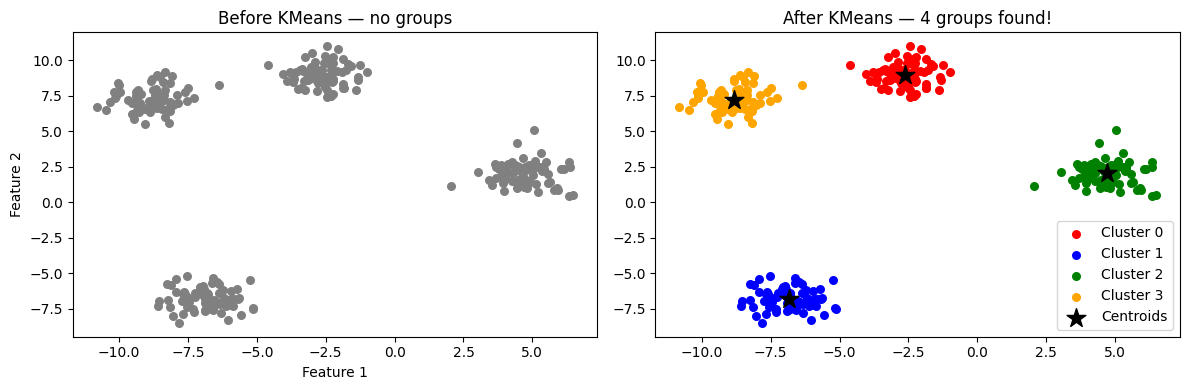

Cluster sizes: [75 75 75 75]
Inertia (lower = tighter clusters): 362.47


In [ ]:
## Day 15 — KMeans Clustering
### Key Learnings:
##- Unsupervised learning finds hidden patterns without labels
#- KMeans assigns every point to its nearest centroid, then moves centroids
#- Always scale features before KMeans — it's distance based
- Elbow method: find the bend in inertia curve
- Silhouette score: higher = better separated clusters
- KMeans found survival patterns on Titanic without seeing survival labels
- Real use: customer segmentation, anomaly detection, data exploration


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')

# Create clear cluster data
X, y_true = make_blobs(n_samples=300, centers=4,
                        cluster_std=0.8, random_state=42)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', s=30)
plt.title("Before KMeans — no groups")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], s=30, label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', s=200, marker='*', label='Centroids', zorder=5)
plt.title("After KMeans — 4 groups found!")
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_visualization.png', dpi=100)
plt.show()

print(f"Cluster sizes: {np.bincount(labels)}")
print(f"Inertia (lower = tighter clusters): {kmeans.inertia_:.2f}")

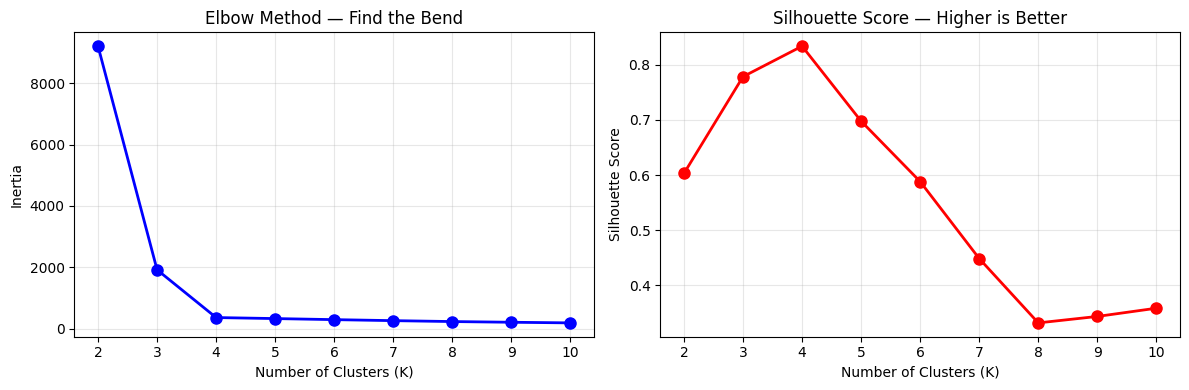

Best K by Silhouette Score: 4

Silhouette Scores:
K=2: ██████████████████ 0.6030
K=3: ███████████████████████ 0.7783
K=4: █████████████████████████ 0.8335
K=5: ████████████████████ 0.6976
K=6: █████████████████ 0.5882
K=7: █████████████ 0.4487
K=8: █████████ 0.3322
K=9: ██████████ 0.3439
K=10: ██████████ 0.3588


In [ ]:
# The biggest question in KMeans — how many clusters?
# Answer: Elbow Method

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_))

plt.figure(figsize=(12, 4))

# Elbow curve
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Find the Bend')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Silhouette score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=100)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"Best K by Silhouette Score: {best_k}")
print(f"\nSilhouette Scores:")
for k, s in zip(K_range, silhouette_scores):
    bar = '█' * int(s * 30)
    print(f"K={k}: {bar} {s:.4f}")

In [ ]:
# Create realistic customer data
np.random.seed(42)
n = 300

customers = pd.DataFrame({
    'Age':              np.concatenate([
                            np.random.normal(25, 3, 80),   # young
                            np.random.normal(45, 5, 120),  # middle aged
                            np.random.normal(65, 4, 100)   # senior
                        ]),
    'Annual_Income':    np.concatenate([
                            np.random.normal(30000, 5000, 80),
                            np.random.normal(70000, 10000, 120),
                            np.random.normal(45000, 8000, 100)
                        ]),
    'Spending_Score':   np.concatenate([
                            np.random.normal(75, 10, 80),
                            np.random.normal(50, 15, 120),
                            np.random.normal(30, 10, 100)
                        ]),
    'Purchase_Freq':    np.concatenate([
                            np.random.normal(20, 4, 80),
                            np.random.normal(12, 3, 120),
                            np.random.normal(6, 2, 100)
                        ])
})

print("Customer Data Sample:")
print(customers.head())
print("\nData Statistics:")
print(customers.describe().round(1))

Customer Data Sample:
         Age  Annual_Income  Spending_Score  Purchase_Freq
0  26.490142   25855.024945       82.569886      21.474693
1  24.585207   27199.094799       65.778347      18.426645
2  26.943066   33736.468026       83.696059      20.114979
3  29.569090   33051.851327       88.556379      25.113807
4  24.297540   29895.492030       79.134349      20.764396

Data Statistics:
         Age  Annual_Income  Spending_Score  Purchase_Freq
count  300.0          300.0           300.0          300.0
mean    46.4        50675.1            50.8           12.4
std     16.2        18213.0            20.4            6.2
min     17.1        22759.6            14.8            0.2
25%     29.5        34112.2            32.9            7.3
50%     46.2        47704.4            49.0           11.9
75%     62.4        64708.7            65.8           16.5
max     80.4       100788.8           100.7           28.7


In [ ]:
# Scale first — KMeans is distance based so scale matters!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customers)

# Find best K
inertias = []
sil_scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

best_k = range(2, 8)[np.argmax(sil_scores)]
print(f"Best number of customer segments: {best_k}")

# Apply best KMeans
kmeans_customers = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers['Cluster'] = kmeans_customers.fit_predict(X_scaled)

# Analyze each cluster
print("\n📊 Customer Segment Profiles:")
print("=" * 60)
cluster_summary = customers.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'Purchase_Freq': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'}).round(1)
print(cluster_summary)

Best number of customer segments: 3

📊 Customer Segment Profiles:
          Age  Annual_Income  Spending_Score  Purchase_Freq  Count
Cluster                                                           
0        45.0        69833.5            50.1           12.5    118
1        64.9        44177.7            32.4            6.3    102
2        24.6        30700.7            75.3           20.2     80


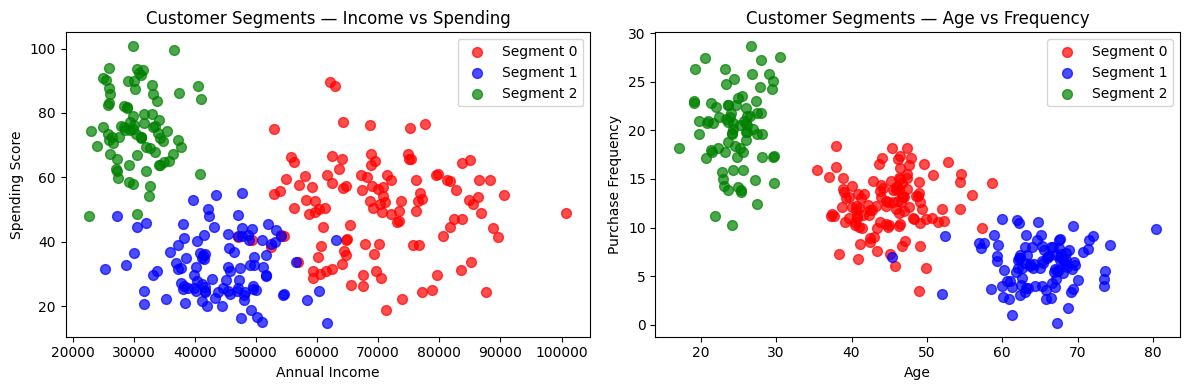

In [ ]:
plt.figure(figsize=(12, 4))

# Income vs Spending
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(best_k):
    mask = customers['Cluster'] == i
    plt.scatter(customers[mask]['Annual_Income'],
                customers[mask]['Spending_Score'],
                c=colors[i], s=50, label=f'Segment {i}', alpha=0.7)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments — Income vs Spending')
plt.legend()

# Age vs Purchase Frequency
plt.subplot(1, 2, 2)
for i in range(best_k):
    mask = customers['Cluster'] == i
    plt.scatter(customers[mask]['Age'],
                customers[mask]['Purchase_Freq'],
                c=colors[i], s=50, label=f'Segment {i}', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Purchase Frequency')
plt.title('Customer Segments — Age vs Frequency')
plt.legend()

plt.tight_layout()
plt.savefig('customer_segments.png', dpi=100)
plt.show()

In [ ]:
# Look at cluster summary and give each segment a name
print("🎯 Business Segment Analysis:")
print("=" * 60)

for cluster_id in sorted(customers['Cluster'].unique()):
    segment = customers[customers['Cluster'] == cluster_id]
    avg_age = segment['Age'].mean()
    avg_income = segment['Annual_Income'].mean()
    avg_spending = segment['Spending_Score'].mean()
    avg_freq = segment['Purchase_Freq'].mean()
    count = len(segment)

    # Name the segment based on characteristics
    if avg_spending > 60:
        name = "💎 High Value Shoppers"
    elif avg_income > 60000:
        name = "💼 Affluent Occasional Buyers"
    elif avg_age > 55:
        name = "🧓 Senior Budget Shoppers"
    else:
        name = "📦 Regular Customers"

    print(f"\nSegment {cluster_id} — {name}")
    print(f"  Count:          {count} customers")
    print(f"  Avg Age:        {avg_age:.1f} years")
    print(f"  Avg Income:     ${avg_income:,.0f}")
    print(f"  Spending Score: {avg_spending:.1f}/100")
    print(f"  Purchase Freq:  {avg_freq:.1f} times/month")

🎯 Business Segment Analysis:

Segment 0 — 💼 Affluent Occasional Buyers
  Count:          118 customers
  Avg Age:        45.0 years
  Avg Income:     $69,834
  Spending Score: 50.1/100
  Purchase Freq:  12.5 times/month

Segment 1 — 🧓 Senior Budget Shoppers
  Count:          102 customers
  Avg Age:        64.9 years
  Avg Income:     $44,178
  Spending Score: 32.4/100
  Purchase Freq:  6.3 times/month

Segment 2 — 💎 High Value Shoppers
  Count:          80 customers
  Avg Age:        24.6 years
  Avg Income:     $30,701
  Spending Score: 75.3/100
  Purchase Freq:  20.2 times/month


In [ ]:
# Can KMeans find survival patterns WITHOUT being told about survival?
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Sex_encoded'] = (df['Sex'] == 'male').astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

features = ['Pclass', 'Sex_encoded', 'Age', 'Fare', 'FamilySize', 'IsAlone']
X_titanic = scaler.fit_transform(df[features])

# Cluster into 2 groups — can it find survivors?
km_titanic = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = km_titanic.fit_predict(X_titanic)

# Check how well clusters align with actual survival
print("KMeans Cluster vs Actual Survival:")
print(pd.crosstab(df['Cluster'], df['Survived'],
      rownames=['Cluster'], colnames=['Survived']))

# Survival rate per cluster
print("\nSurvival rate per cluster:")
print(df.groupby('Cluster')['Survived'].mean().round(3))

KMeans Cluster vs Actual Survival:
Survived    0    1
Cluster           
0         175  185
1         374  157

Survival rate per cluster:
Cluster
0    0.514
1    0.296
Name: Survived, dtype: float64


In [ ]:
print("Cluster Profiles:")
print(df.groupby('Cluster')[['Pclass','Sex_encoded','Age','Fare','FamilySize']].mean().round(2))

Cluster Profiles:
         Pclass  Sex_encoded    Age   Fare  FamilySize
Cluster                                               
0          2.15         0.46  26.73  53.14        3.24
1          2.42         0.77  31.15  18.01        1.00
